In [4]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import numpy               as np
import pandas              as pd
import warnings
warnings.filterwarnings('ignore')
    
from collections           import Counter
from Algorithm             import PAM
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca

In [ ]:
sample_idx = np.random.default_rng(42).choice(len(data_pca), 1000, replace = False)
X2d        = data_pca[sample_idx]

model2d    = PAM(n_clusters = k, random_state = 42)
model2d.fit(X2d)

medoids2d  = X2d[model2d.get_medoids()]
                       for point in data_pca])

plt.figure(figsize = (8, 8))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c = labels2d, alpha = 0.5, cmap = 'tab10')
plt.scatter(medoids2d[:, 0], medoids2d[:, 1], marker = 'D', s = 120, color = 'red', zorder = 5, label = 'Medoids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()

plt.figure(figsize = (8, 8))
plt.scatter(data['balance'], data['purchases'], c = labels, alpha = 0.5, cmap = 'tab10')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.show()

Tiền xử lý dữ liệu

In [5]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.head(2))

    balance  purchases  cash_advance
0 -1.334707  -0.123312     -0.937894
1  0.952729  -1.686451      1.518315


Xây dựng mô hình PAM

In [ ]:
k=3
Pam_model=PAM(n_clusters = k)
(ticks,results) = timedcall(Pam_model.fit(data))
print(f'PAM clustering completed in {ticks:.4f} seconds.')

In [ ]:
## Lưu trữ mô hình để khai thác về sau
medoid_idx = Pam_model.get_medoids()
medoids    = data.iloc[medoid_idx]

jlb.dump(Pam_model, '../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [ ]:
## Khai thác mô hình đã được xây dựng
saved   = jlb.load(Pam_model, '../customer_clustering/Output/PAM.mdl')

In [ ]:
## Kết quả gom cụm khách hàng
data['cluster'] = saved.get_labels()

print('\nKích thước các clusters:', Counter(data['cluster']))
print('\n2 clusters lớn nhất:',    Counter(data['cluster']).most_common(2))


Kích thước các clusters: Counter({np.int64(0): 4431, np.int64(1): 1410, np.int64(3): 1177, np.int64(4): 1165, np.int64(2): 453})

2 clusters lớn nhất: [(np.int64(0), 4431), (np.int64(1), 1410)]


In [ ]:
clusters = saved.get_clusters()
medoids = saved.get_medoids()
labels= saved.get_labels()
print(clusters)
print(medoids)

[[13, 30, 31, 34, 42, 44, 46, 50, 52, 57, 59, 65, 71, 77, 81, 83, 85, 86, 92, 96, 109, 112, 123, 125, 129, 131, 138, 140, 142, 146, 148, 156, 166, 168, 179, 188, 191, 194, 203, 207, 209, 211, 212, 227, 234, 235, 242, 243, 249, 251, 253, 256, 258, 261, 269, 271, 274, 299, 311, 319, 326, 327, 346, 347, 348, 359, 362, 372, 375, 384, 388, 389, 390, 393, 396, 397, 400, 401, 408, 411, 415, 421, 422, 426, 427, 430, 436, 441, 456, 457, 463, 471, 489, 491, 493, 502, 511, 512, 518, 521, 523, 534, 543, 546, 555, 559, 572, 575, 578, 582, 588, 592, 597, 598, 599, 615, 622, 623, 628, 629, 632, 635, 636, 641, 648, 651, 653, 665, 667, 669, 670, 677, 679, 681, 690, 699, 703, 707, 717, 726, 731, 734, 735, 737, 739, 744, 756, 757, 769, 778, 785, 786, 806, 807, 810, 811, 814, 830, 840, 841, 844, 845, 858, 871, 888, 899, 913, 917, 918, 929, 935, 937, 939, 947, 949, 950, 956, 962, 966, 967, 978, 980, 982, 988, 990, 997, 1000, 1001, 1004, 1010, 1015, 1022, 1023, 1024, 1036, 1038, 1041, 1046, 1048, 1053, 1054

Biểu diễn trực quan

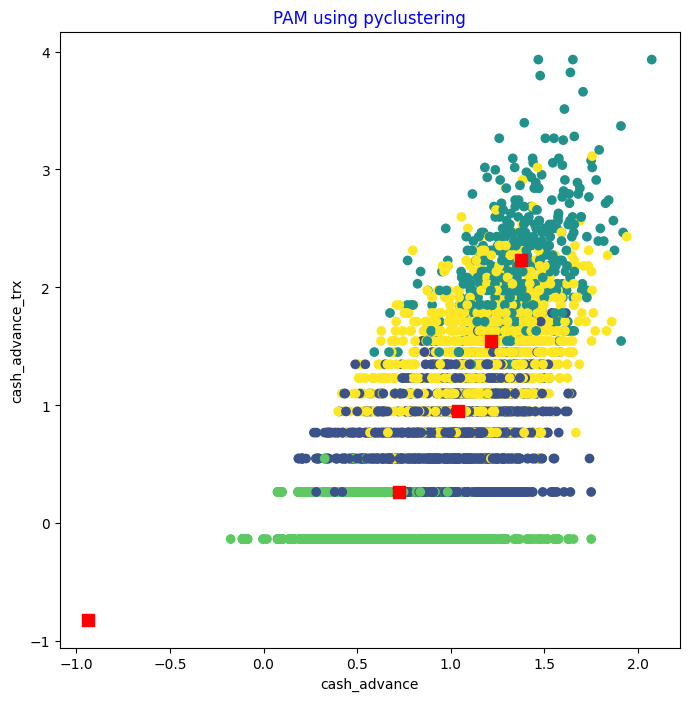

In [ ]:
plt.figure(figsize = (8, 8))
plt.scatter(data['balance'], data['purchases'], c = labels, alpha = 0.5, cmap = 'tab10')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.show()